# MultiModal RAG with Gemini LangChain and Google AI Studio YT

In [1]:
%pip install --upgrade langchain_classic langchain-google-genai "langchain[docarray]" faiss-cpu pypdf langchain-text-splitters langchain-community langchain-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.9/136.9 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.8
    Uninstalling langchain-core-1.4

In [51]:
!pip install pillow

In [2]:
import os
import requests
from PIL import Image

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Markdown

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [7]:
from langchain_core.messages import HumanMessage, SystemMessage

In [8]:
from langchain_classic.vectorstores import DocArrayInMemorySearch

In [9]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

In [10]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

In [11]:
from langchain_classic.schema.document import Document
from langchain_community.document_loaders import TextLoader

In [12]:
from langchain_text_splitters import CharacterTextSplitter

In [13]:
from langchain_community.vectorstores import FAISS

In [62]:
from google.colab import userdata
GOOGLE_API_KEY=userdata.get('Google_API_KEY1')
os.environ["Google_API_KEY1"] = GOOGLE_API_KEY

In [63]:
def load_modal(modal_name):
  if modal_name == "gemini-3-flash-preview":
    llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")
  else:
    llm = ChatGoogleGenerativeAI(model="gemini-1.0-pro-vision")

  return llm

In [33]:
model_text = load_modal("gemini-3-flash-preview")

In [34]:
model_text.invoke("please come up with the best funny line.").content

[{'type': 'text',
  'text': 'Since humor is subjective, here are the best funny lines categorized by the "type" of funny you might be looking for:\n\n### The Best "Unexpected Twist" (Paraprosdokian)\n> "I want to die peacefully in my sleep, just like my grandfather. Not screaming in terror like the passengers in his car."\n\n### The Best "Self-Deprecating" Line\n> "I’m at that age where my back goes out more than I do."\n\n### The Best "Dad Joke" (Clean & Punny)\n> "My wife told me to stop impersonating a flamingo. I had to put my foot down."\n\n### The Best "Modern Relatable" Line\n> "My bed is a magical place where I suddenly remember everything I forgot to do."\n\n### The Best Short One-Liner\n> "I used to be indecisive. Now I’m not sure."\n\n### The Best "Wisdom" Line\n> "Knowledge is knowing a tomato is a fruit; wisdom is not putting it in a fruit salad."\n\n**The Winner (Overall Crowd-Pleaser):**\n> **"I have a lot of jokes about unemployed people, but it doesn\'t matter—none of 

In [29]:
llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")

In [30]:
llm.invoke("please come up with the best funny line.").content

[{'type': 'text',
  'text': 'Since "funny" is subjective, here is a top-tier one-liner that hits the perfect balance of wordplay and imagery:\n\n**"My wife told me to stop impersonating a flamingo. I had to put my foot down."**',
  'extras': {'signature': 'ErMWCrAWARFNMg8sGDVTviQGJTNBWVRMnp9PH034DWDoCrwcuUjmZGJlSRd/EE+xGiC4LS1UKLzYfp6QwEk+QzZF7Fkno/CdIBE4Y+BWA16X/EflNGThCFMz85SEVwWC28yx96YBQjTbKJQU0QCvdPR6ZV62ZVI/7umcS0Vbr8ct49mlCndzNWB/iEhQ0qEFdhZEr3S1vUYpNnh1Fui0LTw0RLERnFbHnw82UAyvu9CLMlv193FpHVckDoN3UuMjRo5x6EbxiCc5pT6931mYkGEhtrKVFx8xw9fxLWP984TN7+X7Nvte+/LTVj7XVR4hDn7gxuOLRO0nnyFlRLLAOes8ozF2/Bf8ekVTGhrw7Ajtv0s/sUYWM8GpeNa4uzUKKJEkRIDybNLBvmJKgbsI6YglQOsoGngWs+I3VH8HA/QaH+75+OdWZs4HpoXowb/TY6EEa8JRuu4s8zgH884S+NGLEvnSGHmp0hNZEkVHh1LHTA0XHNHhxZ+j9bqh49D9O7n6WuA/H5gf8lMSw775DROPUPqZ20y8VcGwy+R0mAJn0+FoE8hUkPf1A2SDXd3hAYyZ0jD1V8SpCDbGZB1k41gdwkL0iHEXi6Vdqc0JiyMv4XvRwtzrifwVGM8F83NH4qT/6we3RsZXlQJYmFcsTqYA8wefclkKjBXNkHn2IVoI4nht5qmpIqtoSwjeIlkqIj6yQd2QN6JYkg5I6mGE/OLppQPuHxIQZv5tFQC

In [36]:
model_text.invoke(
    [
        HumanMessage(content="Answer with Simple 'Yes' or 'No'. Question: Is apple a Fruit?")
    ]
).content

[{'type': 'text',
  'text': 'Yes.',
  'extras': {'signature': 'Eq4CCqsCARFNMg/yXMbmtmcWsh9NTK7kZr+f8QzSRzMvO+CBv6+MGP+uGWtVmvD6OKSCFJ4Zwl5lx8VwXqsA0mjegweLhQh8lsBhGgc+gFvieewA5LdaAX0486ss80580nA9Bh51wQUMGnD2BxWfxMlDvkyPYjiqkGO5CMBzs7JYhntfcp6QiLmCd98SYhDMtyubDcLLxALujCDe8I8v92PI02r6SLKUmsdFz+z6N6N1fwz4cxqr9J3MyzJpwmSKiiBZASYy4E5k8grKrzf7uEGem5iHnzxluBdhdSVvMpnMsODrvWRAAGjKMnuX5gsfyrkEdLft7QhSGuL7oo6OkbJp3QdFs3/Kpg2k+cUi5apxHJfpEC0RNfviGIEBdi4IqnUHzr8uh5Bmq6bD4AuhBOU='}}]

In [37]:
def get_image(url, filename, extension):
  content = requests.get(url).content
  with open(f'/content/{filename}.{extension}', 'wb') as f:
    f.write(content)
  image = Image.open(f"/content/{filename}.{extension}")
  image.show()
  return image

In [38]:
image = get_image("https://static.nike.com/a/images/t_web_pdp_936_v2/f_auto,u_9ddf04c7-2a9a-4d76-add1-d15af8f0263d,c_scale,fl_relative,w_1.0,h_1.0,fl_layer_apply/17b011af-a88f-4853-a8e8-f27b77627ae4/NIKE+MIND+002.png",
                  "nike-shoes",
                  "png")

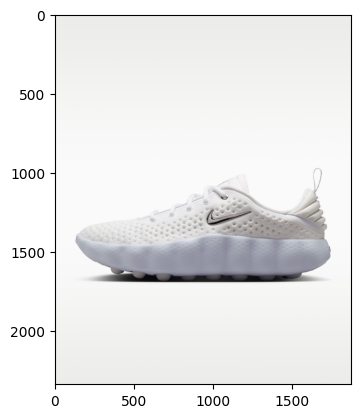

In [39]:
plt.imshow(image)
plt.show()

In [68]:
vision_model=load_modal("gemini-3-flash-preview")

In [69]:
prompt="give me summary of this image in 5 words"

In [70]:
import base64
from io import BytesIO

def pil_image_to_base64(image):
    buffered = BytesIO()
    image.save(buffered, format="JPEG") # You might need to adjust format based on image type
    return base64.b64encode(buffered.getvalue()).decode("utf-8")

base64_image = pil_image_to_base64(image)

message = HumanMessage(
    content = [
        {
            "type": "text",
            "text": prompt,
        },
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}
        }
    ]
)

In [71]:
print(vision_model.invoke([message]).content)

[{'type': 'text', 'text': 'A white Nike golf shoe.', 'extras': {'signature': 'Eo4ICosIARFNMg/lmZNaaUzBCKkqf01ocAr7ufKImd+Tc8wweKSsrBGcfy7bw6EuOJ0wo6ylWifT0PmQ1n/kCymoQ39EuND47huPV9t6OSxaxGlzBaP09RuvQIvJKkkEfqrO+cgG1veXnJ6Zlg8ZHQLKRhQ53shSSu9yJWcjqcQo3z1SH1djzgHoydMKioRUt/YdawK/aCaKrps5PQQ8OXHr1AF4nDQQPeCLWEdNdc7FAEIHWUw+5gEdX0f3RccxWWZI0uSY/SzpOuHZ6TqUAKLQAGdPx6tz96ugsrSDU5hKX/EgHFLo616Q6vOLqGwZ+H1SZETStQQRy65i07ReXb7iTcfRM0VKFVgTJWo0M5IKRTZS7Wegp6Q2BXfNC8ML4p1lCDdDtr61O+qIaEIt5lCMbBP3hdg/bL31X7WDhy49/E+Xbq9R7FxaQ10hcp9lxLC5CZVeOP7kyP3lI5gb6d7mLjZlOqNfd0qfy6LUOD5aL6rrmMivA5+srFzskWO63DTU3l0olw3WKHw5tVIfDJXNNt/2yfJulizflD9HzIXjzgjZaSlRghQzSbuRzAVABjyFdOm++kWn2daJuasAXCRTjrvlYOA6xr96oulSwB2Bggbg3XFA9HYW8AeDEKHXoghpkh5FY4xkbexnhwNqM0+C/fla4YiJLIzj5m6M6hwhs9jeo3iJMsAK+g6bVp9r497y+0lN8iawZhkIRmAXGB3TPL/d4kw6WtKd4wgAw0VADRreCPOTrr4xb+nnbobklVTxcgEPvm8j+4yfdasgzTlbq+g/EBcufHhWyDH1UPLg8WvHOODtLwmbdUkicMe8xxhhHl8BreoLucac83lSrFfywvHFAso/2DQ2azZi4ILGj/UPSKrffOkTe6p8DHOWM0Fb+ks5VZ9WuNwO9OcA1fH7gf

### Google Exmaple

In [60]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
import base64
import os

# Initialize the vision model
llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")

# Prepare your image (e.g., converting to base64)
image_path = "/content/nike-shoes.png"
with open(image_path, "rb") as image_file:
    image_base64 = base64.b64encode(image_file.read()).decode("utf-8")

# Create the multimodal message
message = HumanMessage(
    content=[
        {"type": "text", "text": "Describe what you see in this image and list any key objects."},
        {
            "type": "image_url",
            "image_url": f"data:image/jpeg;base64,{image_base64}",
        },
    ]
)

# Invoke the model
response = llm.invoke([message])
print(response.content)


ChatGoogleGenerativeAIError: Error calling model 'gemini-pro-vision' (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/gemini-pro-vision is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}

In [73]:
loader = TextLoader("/content/nike_shoes")
print(loader.load()[0].page_content)

Shown: White/Vast Grey/Anthracite/Metallic Silver
\n\n

Style: HQ4308-100
\n\n

The American Podiatric Medical Association Seal of Acceptance signals this shoe helps promote good foot health.
\n\n\n

Activate Your Senses
\n
Born from years of research and testing, Nike Mind technology features 22 individually articulated foam nodes that help translate the texture of the ground up to the bottom of your foot.
\n\n\n

Connect Body & Mind
\n
Engaging your senses with Nike Mind can help you get out of your head, connect with your surroundings, and stay more present in the moment.
\n\n\n

Boost Your Brain on the Go
\n
Plush and responsive foam cushioning pairs with a molded heel and sockliner for go-anywhere comfort. Up top, laces anchor your foot closer to the nodes, creating a heightened level of sensation.
\n\n\n




In [74]:
text = loader.load()[0].page_content

In [75]:
def get_text_chunks_langchain(text):
  text_splitter = CharacterTextSplitter(chunk_size=20, chunk_overlap=10)
  docs = [Document(page_content=x) for x in text_splitter.split_text(text)]
  return docs

In [76]:
docs = get_text_chunks_langchain(text)

In [79]:
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2")

In [80]:
vectorstore = FAISS.from_documents(docs, embeddings)

In [81]:
retriever = vectorstore.as_retriever()

In [83]:
retriever.invoke("Nike slide/shoe.")

[Document(id='2c2836e3-ce9d-439b-a789-5e49421fb778', metadata={}, page_content='Style: HQ4308-100\n\\n\\n'),
 Document(id='82f81096-6f55-4f20-8754-a06422a567e5', metadata={}, page_content='Activate Your Senses\n\\n\nBorn from years of research and testing, Nike Mind technology features 22 individually articulated foam nodes that help translate the texture of the ground up to the bottom of your foot.\n\\n\\n\\n'),
 Document(id='7f3fa48e-bd93-4e73-85ba-8ef826e0f9b3', metadata={}, page_content='Connect Body & Mind\n\\n\nEngaging your senses with Nike Mind can help you get out of your head, connect with your surroundings, and stay more present in the moment.\n\\n\\n\\n'),
 Document(id='0c742656-ee2c-499d-bacb-cfd459baf30e', metadata={}, page_content='Shown: White/Vast Grey/Anthracite/Metallic Silver\n\\n\\n')]

In [84]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

In [85]:
llm_vision = load_modal("gemini-3-flash-preview")

In [86]:
llm_text = load_modal("gemini-3-flash-preview")

In [87]:
template = """
```
{context}
```

{query}


Provide brief information and style.
"""

In [88]:
prompt = ChatPromptTemplate.from_template(template)

In [89]:
rag_chain = (
    {"context": retriever, "query": RunnablePassthrough()}
    | prompt
    | llm_text
    | StrOutputParser()
)

In [91]:
result = rag_chain.invoke("can you give me a detail of nike shoel?")

In [92]:
display(Markdown(result))

Based on the documents provided, here are the details for the **Nike Mind** shoe:

### **Product Overview**
The Nike Mind is designed to "activate your senses" using innovative **Nike Mind technology**. It features 22 individually articulated foam nodes on the sole that translate the texture of the ground directly to the bottom of your foot for a unique sensory experience.

### **Key Features**
*   **Sensory Feedback:** The articulated nodes and a specific lacing system anchor the foot closer to the technology to heighten ground sensation.
*   **Comfort:** Includes plush, responsive foam cushioning paired with a molded heel and sockliner for "go-anywhere" comfort.
*   **Design:** Built for a responsive, tactile ride that bridges the gap between the brain and the ground.

### **Style Information**
*   **Style Code:** HQ4308-100
*   **Colorway:** White/Vast Grey/Anthracite/Metallic Silver

In [93]:
rag_chain

{
  context: VectorStoreRetriever(tags=['FAISS', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x7b43d19a80b0>, search_kwargs={}),
  query: RunnablePassthrough()
}
| ChatPromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, template='\n```\n{context}\n```\n\n{query}\n\n\nProvide brief information and style.\n'), additional_kwargs={})])
| ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13', 'langchain-google-genai': '4.2.7'}}, output_version=None, profile={'name': 'Gemini 3 Flash Preview', 'release_date': '2025-12-17', 'last_updated': '2025-12-17', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_i

In [94]:
full_chain = (
    RunnablePassthrough() | llm_vision | StrOutputParser() | rag_chain
)

In [95]:
full_chain

RunnablePassthrough()
| ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13', 'langchain-google-genai': '4.2.7'}}, output_version=None, profile={'name': 'Gemini 3 Flash Preview', 'release_date': '2025-12-17', 'last_updated': '2025-12-17', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-3-flash-preview', temperature=1.0, client=<google.genai.client.Client object at 0x7b43d2fc34d0>, default_metadata=(), model_kwargs={})
| StrOutputParser()
| {
    context: Ve

In [96]:
url_1 = "https://static.nike.com/a/images/t_web_pdp_936_v2/f_auto,u_9ddf04c7-2a9a-4d76-add1-d15af8f0263d,c_scale,fl_relative,w_1.0,h_1.0,fl_layer_apply/17b011af-a88f-4853-a8e8-f27b77627ae4/NIKE+MIND+002.png"

In [97]:
image = get_image(url_1, "nike3", "png")

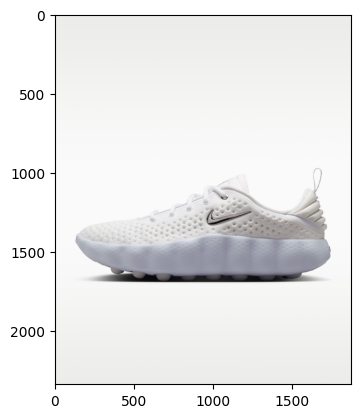

In [98]:
plt.imshow(image)
plt.show()

In [101]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "Provide information on given shoe image Brand and model.",
        },
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{pil_image_to_base64(image)}"}
        },
    ]
)

In [102]:
result = full_chain.invoke([message])

In [103]:
display(Markdown(result))

Based on the provided documents and the style code (HQ4308-100), here is a brief overview of the shoe:

### **Model Information**
*   **Brand/Model:** Nike ISPA MindBody
*   **Style Code:** HQ4308-100
*   **Colorway:** White/Vast Grey/Anthracite/Metallic Silver
*   **Key Technology:** Features **Nike Mind technology**, which utilizes **22 individually articulated foam nodes**. This design is engineered to translate the texture of the ground directly to the bottom of the foot for a sensory experience.

### **Style & Build**
*   **Sensory Design:** The shoe is built around the "Activate Your Senses" philosophy, focusing on ground feel and tactile feedback.
*   **Comfort:** It combines plush, responsive foam cushioning with a molded heel and sockliner for "go-anywhere" comfort.
*   **Upper Construction:** The lacing system is specifically designed to anchor the foot closer to the foam nodes, enhancing the connection between the foot and the cushioning system.
*   **Aesthetic:** True to the ISPA (Improvise. Scavenge. Protect. Adapt.) line, it features an experimental, modular look with a focus on holistic comfort and tactile sensation.